# Regression Models: Decision Tree, Random Forest & XGBoost

In the previous chapter, we saw how powerful linear regression can be when extended to multiple features. But the real world is rarely linear! In this chapter, we will explore three more powerful regression models:

- **Decision Tree Regressor** — a simple, interpretable tree-based model
- **Random Forest Regressor** — an ensemble of decision trees that reduces overfitting
- **XGBoost Regressor** — a gradient boosting model that often tops leaderboards

We will use the **Diabetes dataset** from `sklearn.datasets` — a real-world dataset with 10 clinical features and a continuous target measuring disease progression.

## Data

The Diabetes dataset contains 442 patient records collected from diabetes patients. The target is a quantitative measure of disease progression one year after baseline. It is built into `sklearn` — no file download needed.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
df.shape

(442, 11)

In [7]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


We have **442 rows** and **10 features**: age, sex, BMI, average blood pressure, and six blood serum measurements. The target is disease progression one year after baseline.

**Exercise:** Create the `X` and `y` variables. `X` should contain all feature columns and `y` the target. Both must be `numpy.ndarray`.

In [8]:
X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X type:", type(X))
print("y type:", type(y))

X shape: (442, 10)
y shape: (442,)
X type: <class 'numpy.ndarray'>
y type: <class 'numpy.ndarray'>


### Relationship between variables

**Exercise:** Create a scatter plot for each feature with respect to the target to get a sense of the relationships.

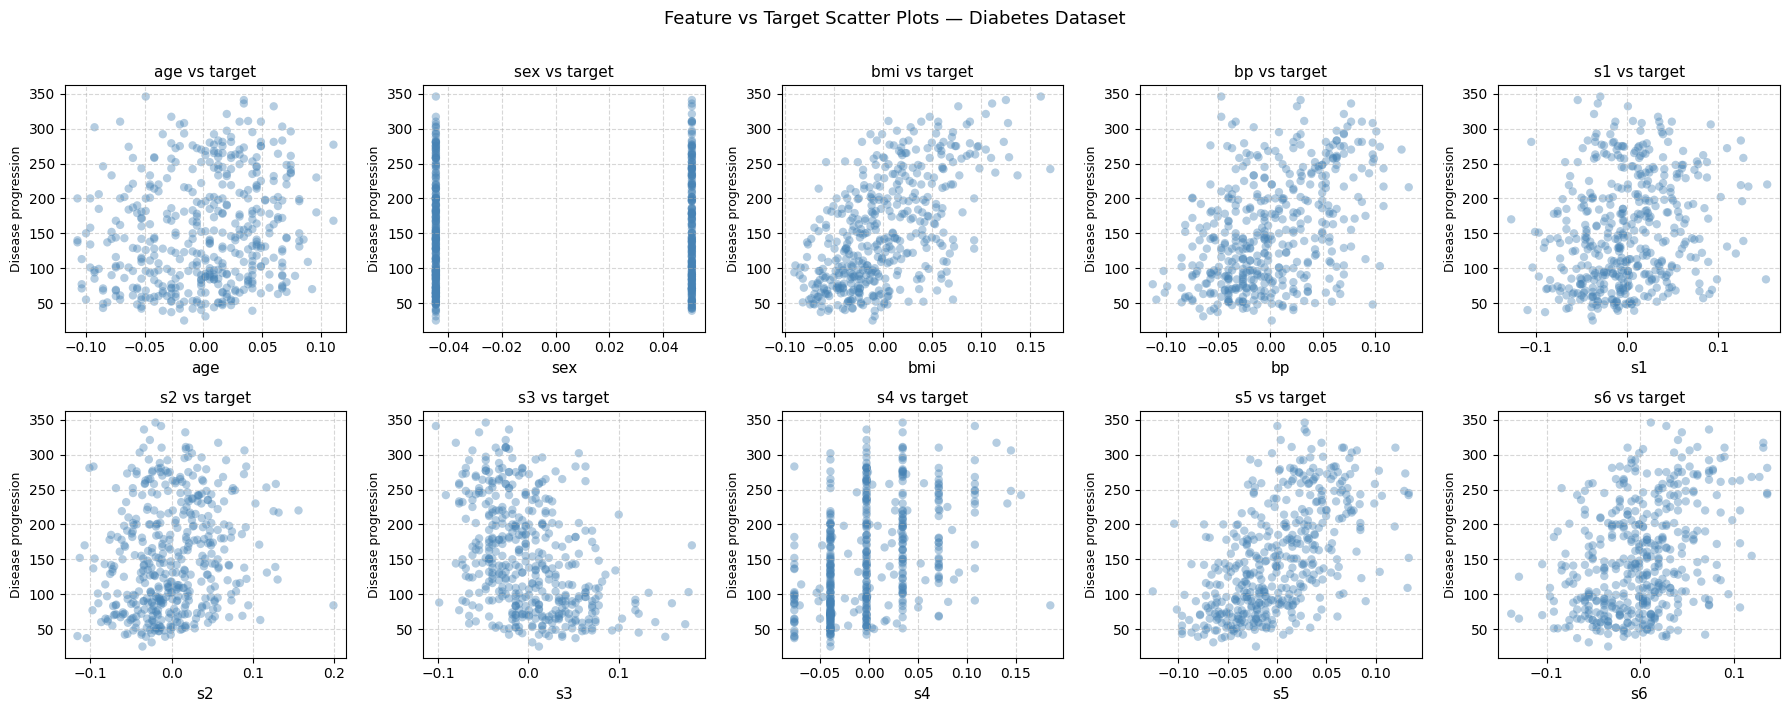

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feature in enumerate(diabetes.feature_names):
    axes[i].scatter(df[feature], df['target'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Disease progression', fontsize=9)
    axes[i].set_title(f'{feature} vs target', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Feature vs Target Scatter Plots — Diabetes Dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Exercise:** Show the correlation coefficients between each feature and the target.

Pearson correlation with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


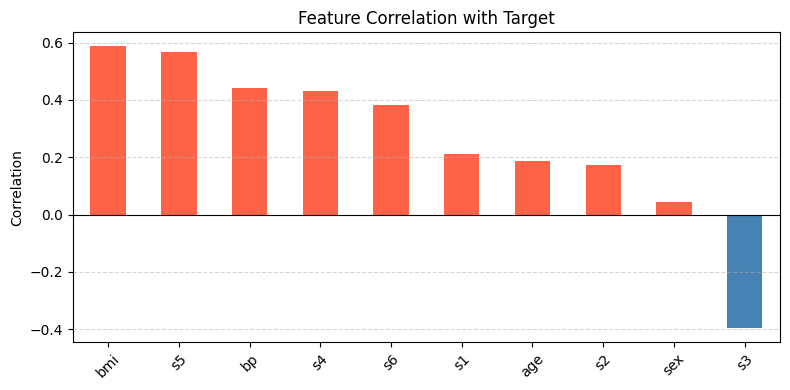

In [10]:
corr = df.corr()['target'].drop('target').sort_values(ascending=False)
print("Pearson correlation with target:")
print(corr)

plt.figure(figsize=(8, 4))
corr.plot(kind='bar', color=['tomato' if c > 0 else 'steelblue' for c in corr])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Correlation')
plt.title('Feature Correlation with Target')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

> **Note:** Pearson correlation only captures *linear* relationships. Features with low correlation may still be informative in non-linear models like trees.

### Split the dataset

**Exercise:** Import `train_test_split` from `sklearn` and split the dataset into `X_train`, `X_test`, `y_train`, `y_test`. Use a test size of 20% and `random_state=42`.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (353, 10)
Test size:  (89, 10)


---
## Model 1 — Decision Tree Regressor

A Decision Tree splits the data into regions based on feature thresholds, making predictions by averaging the target values within each region. It is highly interpretable but prone to **overfitting** when grown too deep.

### How it works
At each node the tree asks a question like *"Is bmi < 0.03?"* and sends data down the left or right branch. The final leaf nodes hold the predicted value.

**Exercise:**
1. Import `DecisionTreeRegressor` from `sklearn.tree`
2. Instantiate it with `random_state=42`
3. Train it on `X_train` and `y_train`
4. Print the train and test R² scores

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

print(f"Decision Tree — Train R²: {dt.score(X_train, y_train):.4f}")
print(f"Decision Tree — Test  R²: {dt.score(X_test, y_test):.4f}")

Decision Tree — Train R²: 1.0000
Decision Tree — Test  R²: 0.0607


You will probably see a **perfect train score (1.0)** but a much lower test score. That's classic overfitting — the tree memorised the training data!

### Controlling overfitting with `max_depth`

**Exercise:** Try different values of `max_depth` and plot train vs test R² to find the sweet spot.

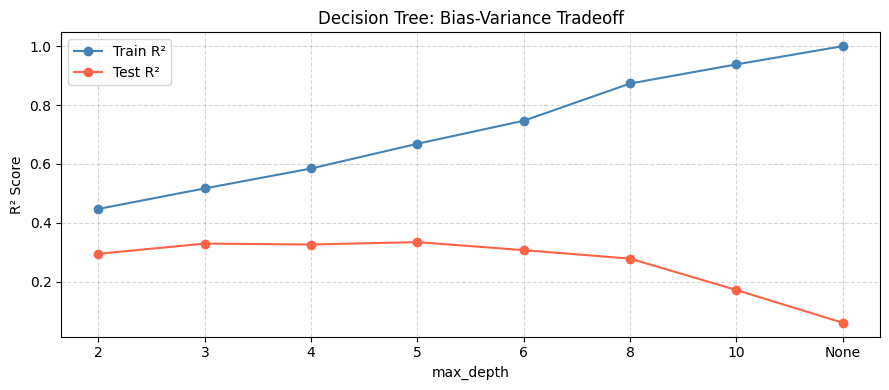

In [13]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
train_scores, test_scores = [], []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

labels = [str(d) if d is not None else 'None' for d in depths]

plt.figure(figsize=(9, 4))
plt.plot(labels, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(labels, test_scores,  marker='o', label='Test R²',  color='tomato')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Decision Tree: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Visualising the tree

One of the biggest strengths of a Decision Tree is its interpretability. Let's visualise a shallow tree.

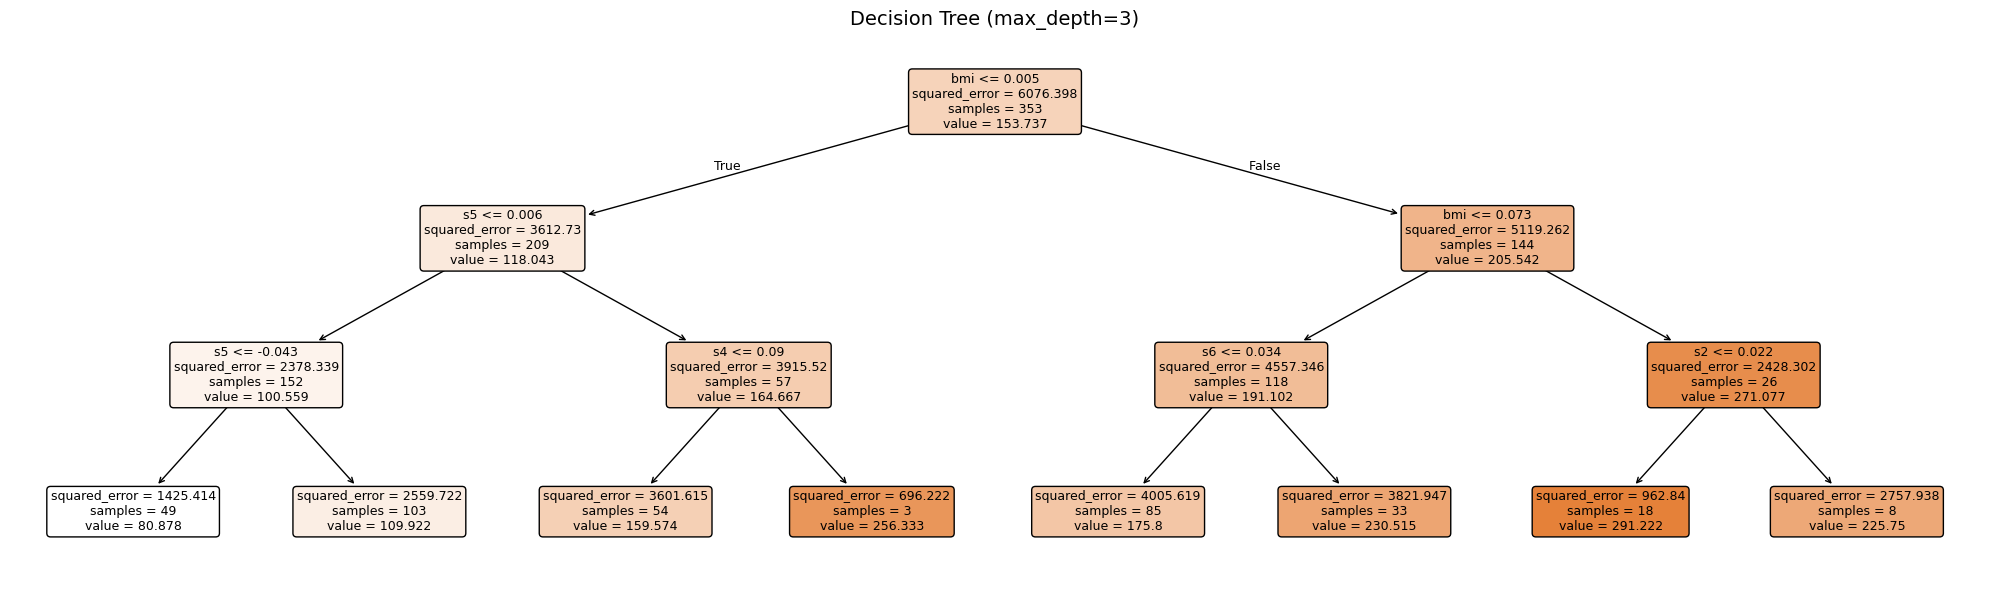

In [14]:
from sklearn.tree import plot_tree

dt_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

plt.figure(figsize=(20, 6))
plot_tree(dt_shallow, feature_names=diabetes.feature_names, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

How would you interpret this visual? What would be your final recommendation to what impacts the diabetes progression?

## Model 2 — Random Forest Regressor

A Random Forest trains **many decision trees** on random subsets of the data and features, then **averages their predictions**. This ensemble approach greatly reduces overfitting compared to a single tree.

### Key hyperparameters
| Parameter | Description |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth of each tree |
| `max_features` | Number of features to consider at each split |
| `min_samples_leaf` | Minimum samples required at a leaf node |

**Exercise:**
1. Import `RandomForestRegressor` from `sklearn.ensemble`
2. Instantiate it with `n_estimators=100` and `random_state=42`
3. Train it and print train/test R² scores

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"Random Forest — Train R²: {rf.score(X_train, y_train):.4f}")
print(f"Random Forest — Test  R²: {rf.score(X_test, y_test):.4f}")

Random Forest — Train R²: 0.9242
Random Forest — Test  R²: 0.4428


### Effect of number of trees

**Exercise:** Plot test R² as a function of `n_estimators` to see when adding more trees stops helping.

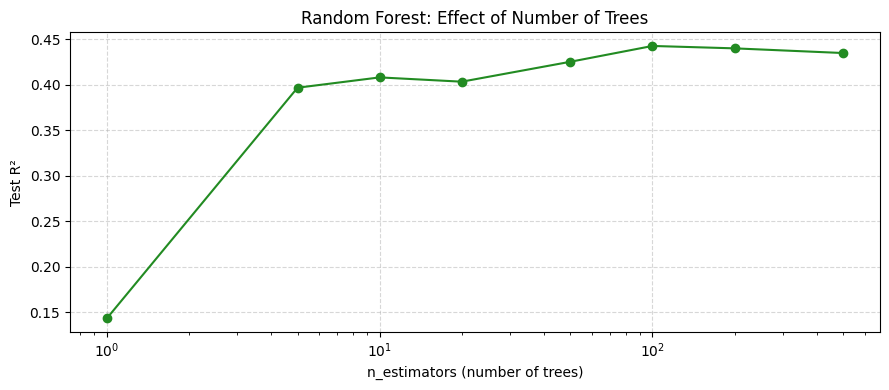

In [17]:
n_trees = [1, 5, 10, 20, 50, 100, 200, 500]
rf_test_scores = []

for n in n_trees:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    rf_test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(n_trees, rf_test_scores, marker='o', color='forestgreen')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Test R²')
plt.title('Random Forest: Effect of Number of Trees')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Importance

Random Forest gives us a built-in way to measure how important each feature was for making predictions.

**Exercise:** Extract and plot the feature importances from your trained Random Forest.

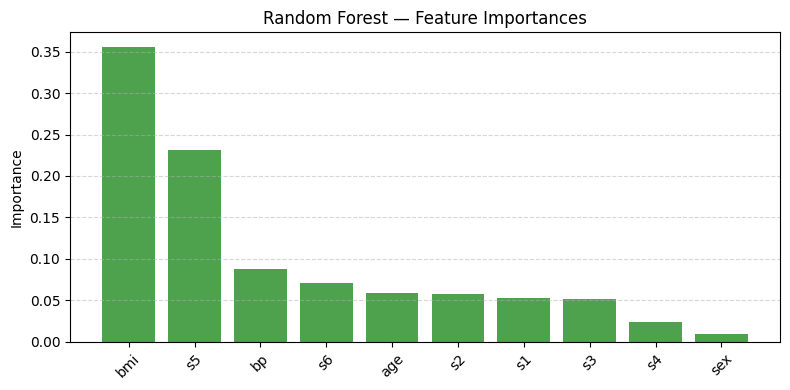

  bmi  : 0.3555
  s5   : 0.2310
  bp   : 0.0884
  s6   : 0.0713
  age  : 0.0586
  s2   : 0.0572
  s1   : 0.0528
  s3   : 0.0513
  s4   : 0.0242
  sex  : 0.0096


In [18]:
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [diabetes.feature_names[i] for i in sorted_idx]

plt.figure(figsize=(8, 4))
plt.bar(sorted_features, importances[sorted_idx], color='forestgreen', alpha=0.8)
plt.ylabel('Importance')
plt.title('Random Forest — Feature Importances')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"  {diabetes.feature_names[i]:5s}: {importances[i]:.4f}")

## Model 3 — XGBoost Regressor

XGBoost (**eXtreme Gradient Boosting**) is another ensemble method, but instead of training trees *independently* (like Random Forest), it trains them **sequentially** — each new tree tries to correct the errors of the previous ones. This is called **gradient boosting**.

XGBoost is famous for winning many machine learning competitions.

### Key hyperparameters
| Parameter | Description |
|---|---|
| `n_estimators` | Number of boosting rounds (trees) |
| `learning_rate` | Shrinks the contribution of each tree (lower = slower but more robust) |
| `max_depth` | Maximum depth of each tree |
| `subsample` | Fraction of training samples used per tree |
| `colsample_bytree` | Fraction of features used per tree |

**Exercise:**
1. Import `XGBRegressor` from `xgboost`
2. Instantiate it with `n_estimators=100`, `learning_rate=0.1`, `random_state=42`
3. Train it and print train/test R² scores

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

print(f"XGBoost — Train R²: {xgb.score(X_train, y_train):.4f}")
print(f"XGBoost — Test  R²: {xgb.score(X_test, y_test):.4f}")

XGBoost — Train R²: 0.9930
XGBoost — Test  R²: 0.3595


### Effect of learning rate

**Exercise:** Try different `learning_rate` values and observe the impact on train and test R². Keep `n_estimators=200`.

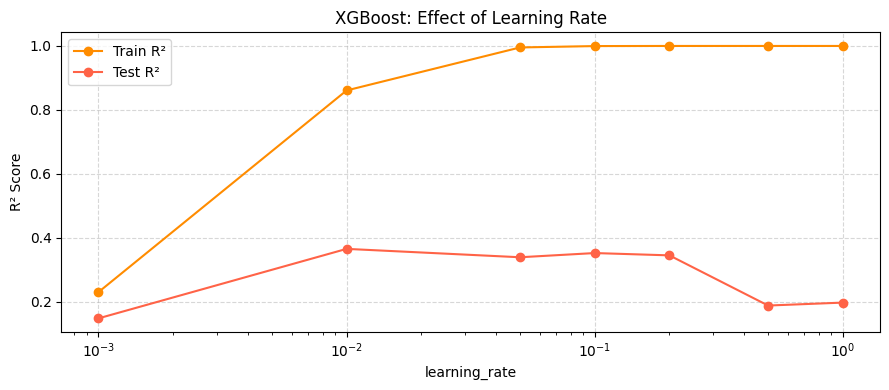

In [20]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
xgb_train_scores, xgb_test_scores = [], []

for lr in learning_rates:
    model = XGBRegressor(n_estimators=200, learning_rate=lr, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    xgb_train_scores.append(model.score(X_train, y_train))
    xgb_test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(learning_rates, xgb_train_scores, marker='o', label='Train R²', color='darkorange')
plt.plot(learning_rates, xgb_test_scores,  marker='o', label='Test R²',  color='tomato')
plt.xlabel('learning_rate')
plt.ylabel('R² Score')
plt.title('XGBoost: Effect of Learning Rate')
plt.xscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Early Stopping

XGBoost supports **early stopping**: training automatically stops when the validation score stops improving, preventing overfitting without manually tuning `n_estimators`.

In [21]:
xgb_es = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=20
)

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgb_es.best_iteration}")
print(f"XGBoost (early stop) — Test R²: {xgb_es.score(X_test, y_test):.4f}")

Best iteration: 33
XGBoost (early stop) — Test R²: 0.3714


---
## Model Comparison

Let's evaluate all models side by side using multiple metrics.

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Decision Tree (depth=3)': DecisionTreeRegressor(max_depth=3, random_state=42),
    'Random Forest (100 trees)': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost (lr=0.1)': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train R²': round(model.score(X_train, y_train), 4),
        'Test R²':  round(r2_score(y_test, y_pred), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'Test MAE':  round(mean_absolute_error(y_test, y_pred), 2),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train R²,Test R²,Test RMSE,Test MAE
Model,,,,
Decision Tree (depth=3),0.5170,0.3294,59.60,48.10
Random Forest (100 trees),0.9242,0.4428,54.33,44.05
XGBoost (lr=0.1),0.9930,0.3595,58.25,46.73


### Predicted vs Actual

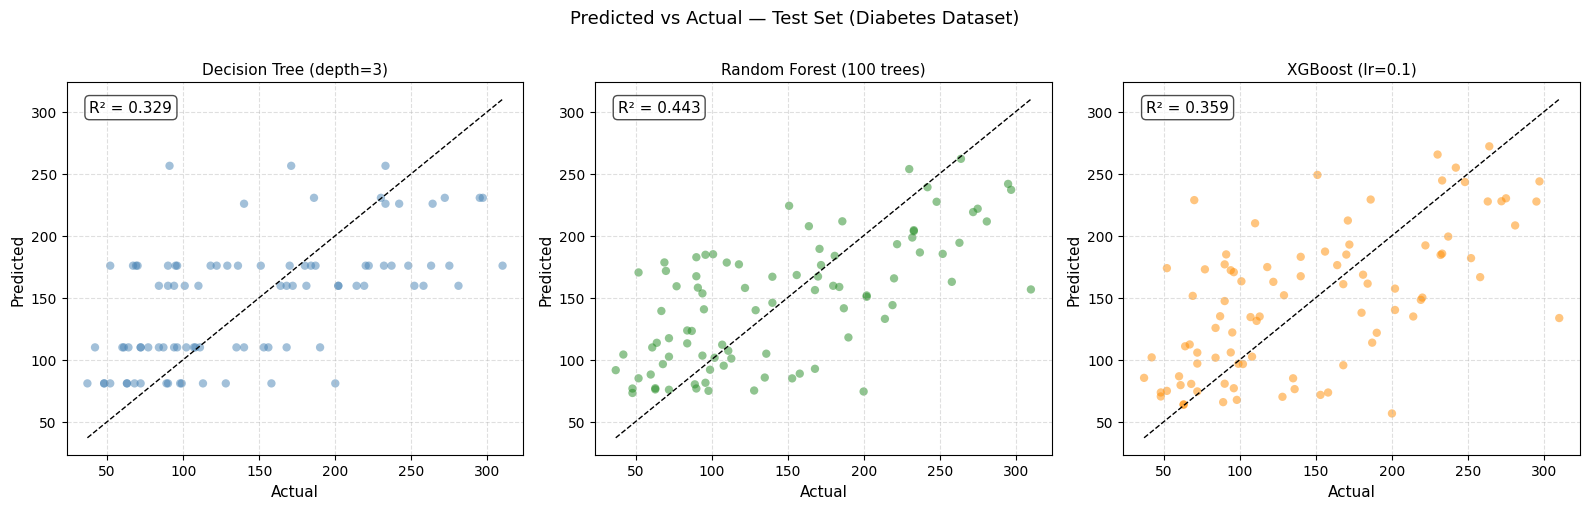

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'forestgreen', 'darkorange']

for ax, (name, model), color in zip(axes, models.items(), colors):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(name, fontsize=11)
    r2 = r2_score(y_test, y_pred)
    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Predicted vs Actual — Test Set (Diabetes Dataset)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Residuals plot

A residuals plot (error vs predicted value) helps diagnose whether a model's errors are random (good) or have patterns (bad).

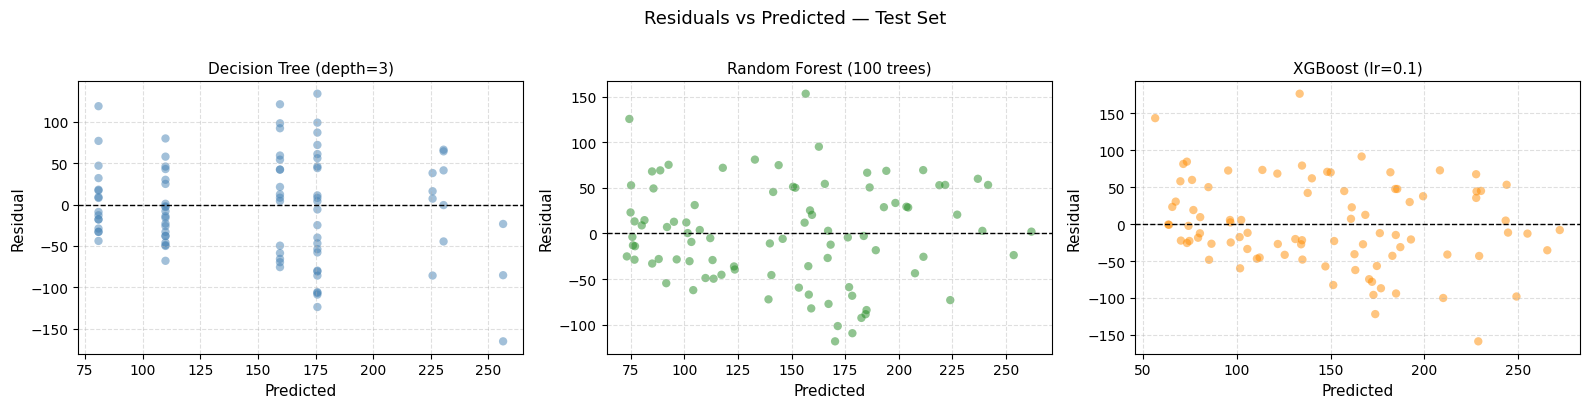

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model), color in zip(axes, models.items(), colors):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color=color, edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Residual', fontsize=11)
    ax.set_title(name, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Residuals vs Predicted — Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Hyperparameter Tuning with Cross-Validation

So far we've tuned hyperparameters by hand. `sklearn` provides `GridSearchCV` to search systematically over a parameter grid using cross-validation.

**Exercise:** Use `GridSearchCV` to find the best `max_depth` and `n_estimators` for the Random Forest.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV R²:      {grid_search.best_score_:.4f}")
print(f"Test R²:         {grid_search.best_estimator_.score(X_test, y_test):.4f}")

Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV R²:      0.4079
Test R²:         0.4544


---
## Summary

| Model | Strengths | Weaknesses |
|---|---|---|
| **Decision Tree** | Interpretable, fast, no feature scaling needed | Prone to overfitting, high variance |
| **Random Forest** | Robust, handles non-linearity, feature importance | Slower, less interpretable than a single tree |
| **XGBoost** | High accuracy, early stopping, built-in regularisation | More hyperparameters to tune, harder to interpret |

### Key takeaways
- **Tree-based models** naturally handle non-linear relationships and feature interactions without feature engineering.
- **Random Forest** reduces variance by averaging many trees trained on random subsets.
- **XGBoost** reduces bias by training trees sequentially, each correcting the errors of the last.
- Always check for **overfitting** by comparing train vs test scores.
- Use **cross-validation** (`GridSearchCV`) for reliable hyperparameter tuning.